# 06. Results Integration & Analysis
**GA-Optimized G-CTGAN: An Automated Oversampling Framework for Imbalanced Data Classification**

This notebook integrates all experimental results and produces:
- Full results table (Table format for paper)
- Dataset-level AUC heatmap
- Per-classifier AUC comparison
- Ranking analysis

**Data sources:**
| File | Contents |
|------|----------|
| `02_baselines_results.csv` | None, SMOTE, ADASYN, G-SMOTE, CTGAN, TVAE |
| `03_ctabgan_results.csv` | CTAB-GAN+ (7 datasets, RF/MLP only) |
| `04_gctgan_results.csv` | G-CTGAN (11 datasets) |
| `05_ga_gctgan_results.csv` | GA-G-CTGAN (6 applicable datasets) |


## 0. Setup

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

warnings.filterwarnings("ignore")

RESULTS_DIR = "./results"
os.makedirs(RESULTS_DIR, exist_ok=True)

# ── Applicable datasets per method ─────────────────────────────────────
ALL_DATASETS = [
    "credit_default", "fraud_detection", "pima_diabetes", "ibm_attrition",
    "yeast_me2", "mammography", "abalone_19", "wine_quality",
    "ecoli", "pageblocks", "protein_homo",
]

# GA-G-CTGAN: IR ≤ 50 and minority n ≥ 100
GA_APPLICABLE = [
    "credit_default", "pima_diabetes", "ibm_attrition",
    "yeast_me2", "wine_quality", "ecoli",
]

# CTAB-GAN+: excluded extreme IR and mixed-type incompatibility
CTABGAN_APPLICABLE = [
    "credit_default", "pima_diabetes", "yeast_me2",
    "mammography", "wine_quality", "ecoli", "pageblocks",
]

METHOD_ORDER = [
    "None", "SMOTE", "ADASYN", "G-SMOTE",
    "CTGAN", "TVAE", "CTAB-GAN+", "G-CTGAN", "GA-G-CTGAN"
]

CLASSIFIERS = ["RF", "LGBM", "MLP"]

print("Setup complete.")
print(f"Total datasets : {len(ALL_DATASETS)}")
print(f"GA-G-CTGAN applicable : {GA_APPLICABLE}")
print(f"CTAB-GAN+ applicable  : {CTABGAN_APPLICABLE}")


Setup complete.
Total datasets : 11
GA-G-CTGAN applicable : ['credit_default', 'pima_diabetes', 'ibm_attrition', 'yeast_me2', 'wine_quality', 'ecoli']
CTAB-GAN+ applicable  : ['credit_default', 'pima_diabetes', 'yeast_me2', 'mammography', 'wine_quality', 'ecoli', 'pageblocks']


## 1. Load & Merge Results

In [2]:
dfs = []

# Baselines
path = os.path.join(RESULTS_DIR, "02_baselines_results.csv")
if os.path.exists(path):
    dfs.append(pd.read_csv(path))
    print(f"  ✓ 02_baselines_results  ({len(dfs[-1])} rows)")

# CTAB-GAN+
path = os.path.join(RESULTS_DIR, "03_ctabgan_results.csv")
if os.path.exists(path):
    df = pd.read_csv(path)
    df = df[df["dataset"].isin(CTABGAN_APPLICABLE)]
    dfs.append(df)
    print(f"  ✓ 03_ctabgan_results    ({len(df)} rows, filtered)")

# G-CTGAN
path = os.path.join(RESULTS_DIR, "04_gctgan_results.csv")
if os.path.exists(path):
    dfs.append(pd.read_csv(path))
    print(f"  ✓ 04_gctgan_results     ({len(dfs[-1])} rows)")

# GA-G-CTGAN (filter applicable datasets only)
path = os.path.join(RESULTS_DIR, "05_ga_gctgan_results.csv")
if os.path.exists(path):
    df = pd.read_csv(path)
    df = df[df["dataset"].isin(GA_APPLICABLE)]
    dfs.append(df)
    print(f"  ✓ 05_ga_gctgan_results  ({len(df)} rows, filtered)")

combined = pd.concat(dfs, ignore_index=True)
combined  = combined[combined["classifier"].isin(CLASSIFIERS)]

print(f"\nTotal combined rows: {len(combined)}")
print(f"Methods found: {combined['oversampling'].unique().tolist()}")
print(f"Classifiers  : {combined['classifier'].unique().tolist()}")


  ✓ 02_baselines_results  (198 rows)
  ✓ 03_ctabgan_results    (14 rows, filtered)
  ✓ 04_gctgan_results     (33 rows)
  ✓ 05_ga_gctgan_results  (18 rows, filtered)

Total combined rows: 263
Methods found: [nan, 'SMOTE', 'ADASYN', 'G-SMOTE', 'CTGAN', 'TVAE', 'CTAB-GAN+', 'G-CTGAN', 'GA-G-CTGAN']
Classifiers  : ['RF', 'LGBM', 'MLP']


## 2. Full AUC Table (Paper Table Format)

In [3]:
def make_auc_table(clf_name):
    """
    Build AUC table for one classifier:
    rows = datasets, columns = methods
    N/A for inapplicable method-dataset combinations.
    """
    sub = combined[combined["classifier"] == clf_name]
    pivot = sub.pivot_table(
        index="dataset", columns="oversampling", values="AUC", aggfunc="mean"
    )

    # Reindex to full dataset × method grid
    pivot = pivot.reindex(index=ALL_DATASETS,
                          columns=[m for m in METHOD_ORDER if m in pivot.columns])
    return pivot

for clf in CLASSIFIERS:
    tbl = make_auc_table(clf)
    print(f"\n{'='*80}")
    print(f"AUC Results — Classifier: {clf}")
    print(f"{'='*80}")

    # Format: bold best per row, N/A for missing
    def fmt(v):
        if pd.isna(v):
            return "  N/A  "
        return f" {v:.4f}"

    print(f"{'Dataset':<22}", end="")
    for col in tbl.columns:
        print(f"{col:>11}", end="")
    print()
    print("-" * (22 + 11 * len(tbl.columns)))

    for ds in tbl.index:
        row = tbl.loc[ds]
        best_val = row.dropna().max() if not row.dropna().empty else None
        print(f"{ds:<22}", end="")
        for col in tbl.columns:
            val = row[col]
            s   = fmt(val)
            if not pd.isna(val) and best_val is not None and abs(val - best_val) < 1e-6:
                s = f"*{val:.4f}"  # mark best
            print(f"{s:>11}", end="")
        print()

    # Mean row (exclude N/A)
    print("-" * (22 + 11 * len(tbl.columns)))
    print(f"{'Mean':<22}", end="")
    for col in tbl.columns:
        mean_val = tbl[col].mean(skipna=True)
        print(f"{mean_val:>11.4f}", end="")
    print()



AUC Results — Classifier: RF
Dataset                     SMOTE     ADASYN    G-SMOTE      CTGAN       TVAE  CTAB-GAN+    G-CTGAN GA-G-CTGAN
--------------------------------------------------------------------------------------------------------------
credit_default            *0.7733     0.7684     0.7517     0.7655     0.7632     0.7613     0.7636     0.7650
fraud_detection           *0.9763     0.9753     0.9756     0.9639     0.9551      N/A       0.9618      N/A  
pima_diabetes              0.8426    *0.8442     0.8355     0.8048     0.8349     0.8363     0.8002     0.8187
ibm_attrition              0.7797    *0.7888    *0.7888     0.7665     0.7780      N/A       0.7754     0.7650
yeast_me2                  0.9027     0.8919     0.9058     0.9225     0.9145     0.9101     0.9183    *0.9318
mammography               *0.9700     0.9648     0.9689     0.9533     0.9610     0.9493     0.9542      N/A  
abalone_19                 0.8096     0.8259    *0.8412     0.7520     0.7580     

## 3. Save Full Table to CSV

In [4]:
all_tables = []
for clf in CLASSIFIERS:
    tbl = make_auc_table(clf)
    tbl.columns.name = None
    tbl.index.name   = "dataset"
    tbl["classifier"] = clf
    all_tables.append(tbl.reset_index())

full_table = pd.concat(all_tables, ignore_index=True)
save_path  = os.path.join(RESULTS_DIR, "06_full_auc_table.csv")
full_table.to_csv(save_path, index=False)
print(f"Full AUC table saved → {save_path}")


Full AUC table saved → ./results\06_full_auc_table.csv


## 4. AUC Heatmap by Dataset × Method

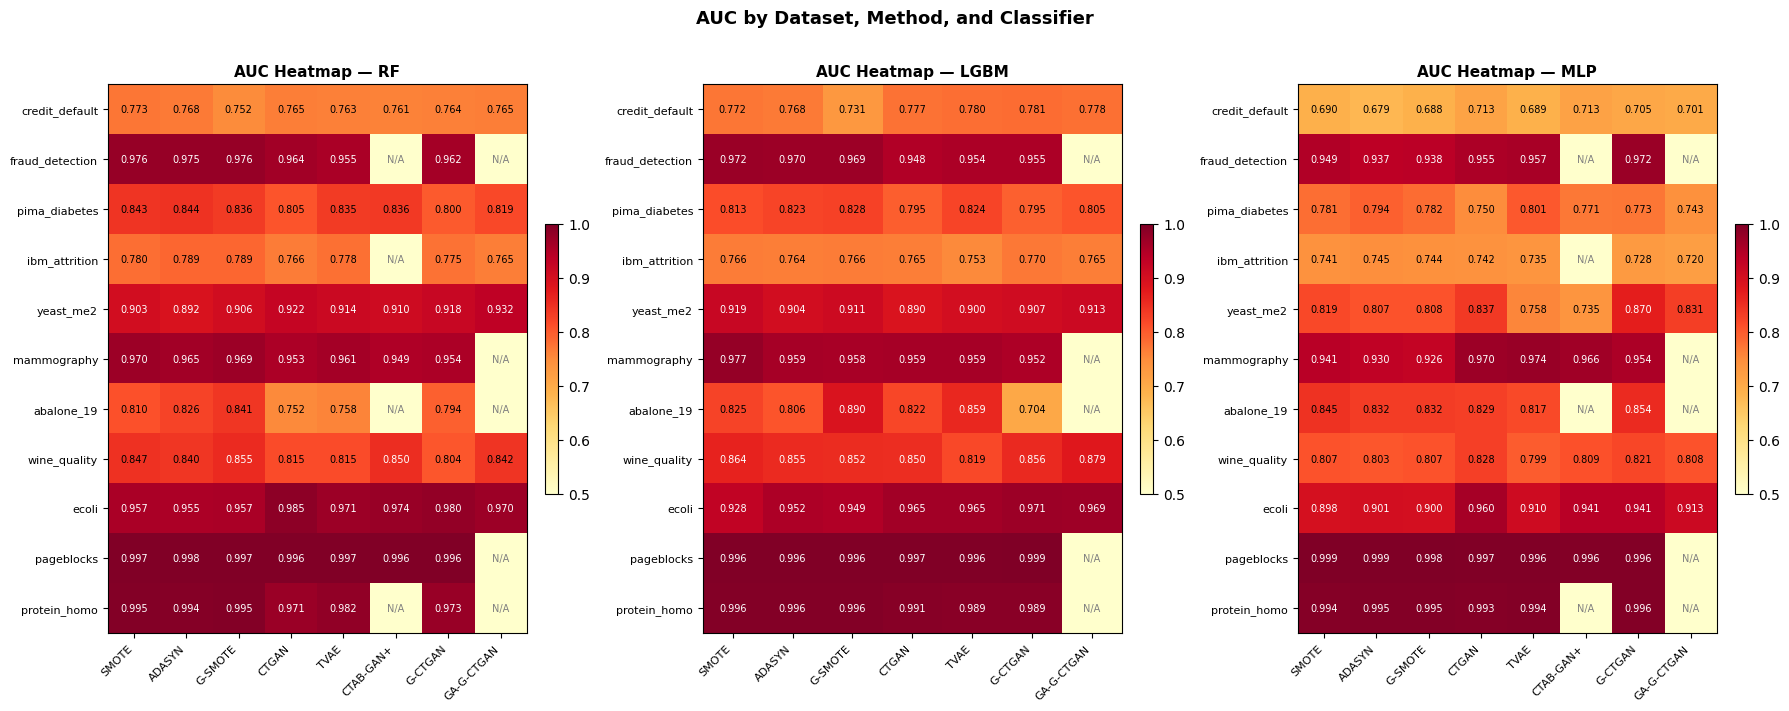

Figure saved → ./results\06_auc_heatmap.png


In [5]:
fig, axes = plt.subplots(1, len(CLASSIFIERS), figsize=(6 * len(CLASSIFIERS), 7))

for ax, clf in zip(axes, CLASSIFIERS):
    tbl = make_auc_table(clf)

    # Color map — gray for N/A
    data     = tbl.values.astype(float)
    mask_na  = np.isnan(data)
    data_filled = np.where(mask_na, 0, data)

    im = ax.imshow(data_filled, cmap="YlOrRd", vmin=0.5, vmax=1.0, aspect="auto")

    # Annotate cells
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            if mask_na[i, j]:
                ax.text(j, i, "N/A", ha="center", va="center",
                        fontsize=7, color="gray")
            else:
                ax.text(j, i, f"{data[i,j]:.3f}", ha="center", va="center",
                        fontsize=7,
                        color="white" if data[i,j] > 0.85 else "black")

    ax.set_xticks(range(len(tbl.columns)))
    ax.set_xticklabels(tbl.columns, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(len(tbl.index)))
    ax.set_yticklabels(tbl.index, fontsize=8)
    ax.set_title(f"AUC Heatmap — {clf}", fontsize=11, fontweight="bold")
    plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04)

plt.suptitle("AUC by Dataset, Method, and Classifier",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
fig_path = os.path.join(RESULTS_DIR, "06_auc_heatmap.png")
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure saved → {fig_path}")


## 5. Mean AUC Comparison (All Methods)

Mean AUC (averaged over applicable datasets per method):
classifier      LGBM     MLP      RF
oversampling                        
SMOTE         0.8935  0.8604  0.8954
ADASYN        0.8903  0.8566  0.8950
G-SMOTE       0.8950  0.8561  0.8974
CTGAN         0.8872  0.8701  0.8815
TVAE          0.8908  0.8573  0.8844
CTAB-GAN+        NaN  0.8472  0.8968
G-CTGAN       0.8798  0.8736  0.8836
GA-G-CTGAN    0.8515  0.7861  0.8487


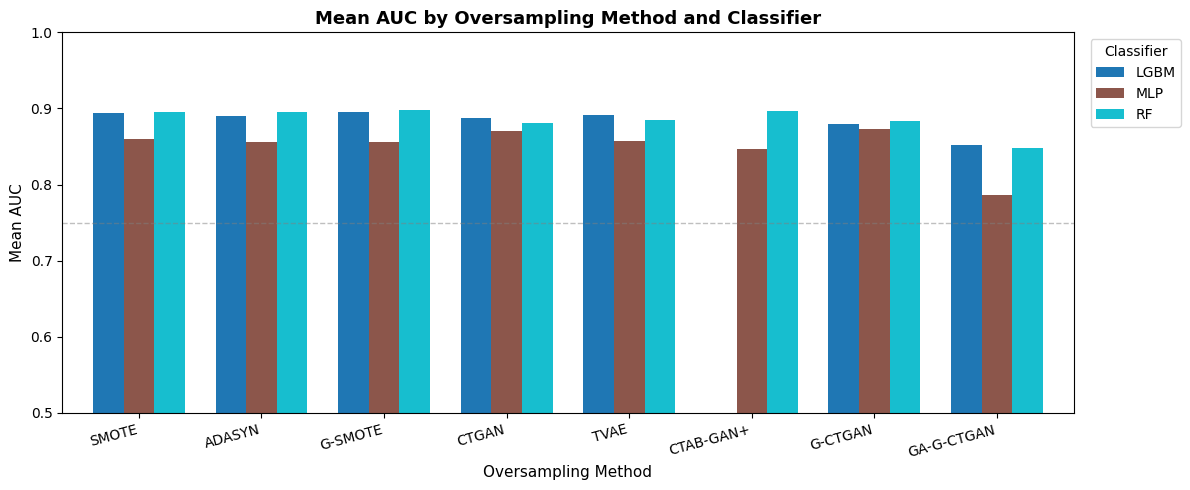

Figure saved → ./results\06_mean_auc_comparison.png


In [6]:
# Mean AUC per method × classifier (over applicable datasets)
pivot_mean = (combined
              .groupby(["oversampling", "classifier"])["AUC"]
              .mean()
              .unstack())
pivot_mean = pivot_mean.reindex([m for m in METHOD_ORDER if m in pivot_mean.index])

print("Mean AUC (averaged over applicable datasets per method):")
print(pivot_mean.round(4).to_string())

fig, ax = plt.subplots(figsize=(12, 5))
pivot_mean.plot(kind="bar", ax=ax, width=0.75, colormap="tab10")
ax.set_title("Mean AUC by Oversampling Method and Classifier",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Oversampling Method", fontsize=11)
ax.set_ylabel("Mean AUC", fontsize=11)
ax.set_ylim(0.5, 1.0)
ax.axhline(0.75, color="gray", linestyle="--", linewidth=1, alpha=0.5)
ax.legend(title="Classifier", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha="right")
plt.tight_layout()
fig_path = os.path.join(RESULTS_DIR, "06_mean_auc_comparison.png")
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure saved → {fig_path}")


## 6. GA-G-CTGAN vs G-CTGAN (Applicable Datasets Only)

In [7]:
# Direct comparison on the 6 GA-applicable datasets
ga_sub = combined[
    (combined["dataset"].isin(GA_APPLICABLE)) &
    (combined["oversampling"].isin(["G-CTGAN", "GA-G-CTGAN"]))
]

pivot_ga = ga_sub.pivot_table(
    index="dataset", columns=["oversampling", "classifier"],
    values="AUC", aggfunc="mean"
)

print("G-CTGAN vs GA-G-CTGAN (AUC) — applicable datasets:")
print(pivot_ga.round(4).to_string())

# Delta: GA-G-CTGAN - G-CTGAN
print("\nDelta (GA-G-CTGAN − G-CTGAN):")
for clf in CLASSIFIERS:
    if ("GA-G-CTGAN", clf) in pivot_ga.columns and ("G-CTGAN", clf) in pivot_ga.columns:
        delta = pivot_ga[("GA-G-CTGAN", clf)] - pivot_ga[("G-CTGAN", clf)]
        mean_delta = delta.mean()
        wins  = (delta > 0).sum()
        print(f"  {clf}: mean_delta={mean_delta:+.4f}  wins={wins}/{len(delta)}")


G-CTGAN vs GA-G-CTGAN (AUC) — applicable datasets:
oversampling   G-CTGAN                 GA-G-CTGAN                
classifier        LGBM     MLP      RF       LGBM     MLP      RF
dataset                                                          
credit_default  0.7813  0.7053  0.7636     0.7785  0.7006  0.7650
ecoli           0.9707  0.9414  0.9798     0.9687  0.9131  0.9697
ibm_attrition   0.7702  0.7275  0.7754     0.7646  0.7204  0.7650
pima_diabetes   0.7946  0.7734  0.8002     0.8051  0.7430  0.8187
wine_quality    0.8560  0.8205  0.8040     0.8790  0.8082  0.8419
yeast_me2       0.9066  0.8704  0.9183     0.9129  0.8311  0.9318

Delta (GA-G-CTGAN − G-CTGAN):
  RF: mean_delta=+0.0085  wins=4/6
  LGBM: mean_delta=+0.0049  wins=3/6
  MLP: mean_delta=-0.0203  wins=0/6


## 7. Method Ranking per Dataset

Mean Rank by Method (lower = better):
oversampling
SMOTE         3.39
G-SMOTE       3.85
ADASYN        3.97
G-CTGAN       3.97
GA-G-CTGAN    4.17
CTGAN         4.24
CTAB-GAN+     4.36
TVAE          4.55


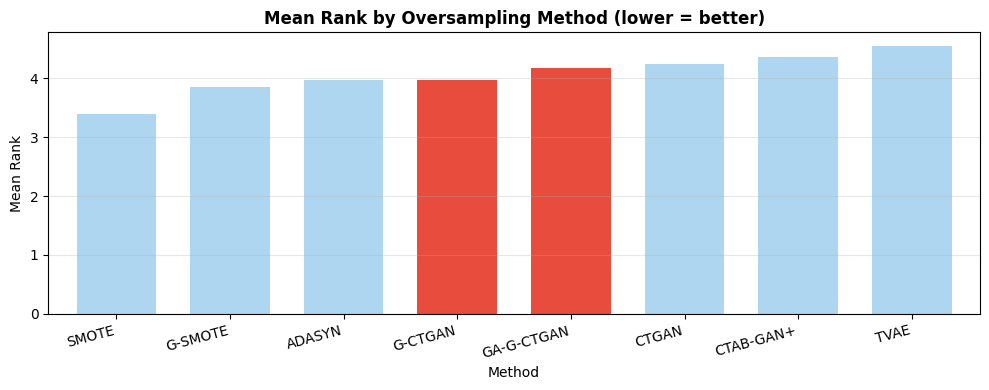

Figure saved → ./results\06_mean_rank.png
Rank data saved → ./results\06_rank_summary.csv


In [8]:
# Average rank across classifiers per dataset
rank_rows = []
for ds in ALL_DATASETS:
    sub = combined[combined["dataset"] == ds]
    if sub.empty:
        continue
    for clf in CLASSIFIERS:
        clf_sub = sub[sub["classifier"] == clf][["oversampling","AUC"]].dropna()
        if clf_sub.empty:
            continue
        clf_sub = clf_sub.sort_values("AUC", ascending=False).reset_index(drop=True)
        for rank, row in clf_sub.iterrows():
            rank_rows.append({
                "dataset"    : ds,
                "classifier" : clf,
                "oversampling": row["oversampling"],
                "AUC"        : row["AUC"],
                "rank"       : rank + 1,
            })

rank_df = pd.DataFrame(rank_rows)
mean_rank = (rank_df.groupby("oversampling")["rank"]
             .mean()
             .sort_values()
             .round(2))

print("Mean Rank by Method (lower = better):")
print(mean_rank.to_string())

# Bar chart
fig, ax = plt.subplots(figsize=(10, 4))
colors = ["#E74C3C" if m in ["GA-G-CTGAN", "G-CTGAN"] else "#AED6F1"
          for m in mean_rank.index]
mean_rank.plot(kind="bar", ax=ax, color=colors, width=0.7)
ax.set_title("Mean Rank by Oversampling Method (lower = better)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Method", fontsize=10)
ax.set_ylabel("Mean Rank", fontsize=10)
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha="right")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
fig_path = os.path.join(RESULTS_DIR, "06_mean_rank.png")
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure saved → {fig_path}")

# Save rank summary
rank_save = os.path.join(RESULTS_DIR, "06_rank_summary.csv")
rank_df.to_csv(rank_save, index=False)
print(f"Rank data saved → {rank_save}")
